DL Assignment 10

Name - Nikhil Sanjay Patil

Class - CS(AI) B

Batch - 01

Roll no - 06

PRN - 12311506




In [ ]:
import kagglehub


path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")

print("Path to dataset files:", path)

100%|██████████| 22.0k/22.0k [00:00<00:00, 30.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3


In [ ]:
import pandas as pd
import os

path = "/root/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3"

print(os.listdir(path))

['DailyDelhiClimateTrain.csv', 'DailyDelhiClimateTest.csv']


In [ ]:
df = pd.read_csv(os.path.join(path, "DailyDelhiClimateTrain.csv"))

df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB
None
          meantemp     humidity   wind_speed  meanpressure
count  1462.000000  1462.000000  1462.000000   1462.000000
mean     25.495521    60.771702     6.802209   1011.104548
std       7.348103    16.769652     4.561602    180.231668
min       6.000000    13.428571     0.000000     -3.041667
25%      18.857143    50.375000     3.475000   1001.580357
50%      27.714286    62.625000     6.221667   1008.563492
75%      31.305804    72.218750     9.238235   1014.944901
max      38.714286   100.000000    42.220000   7679.333333


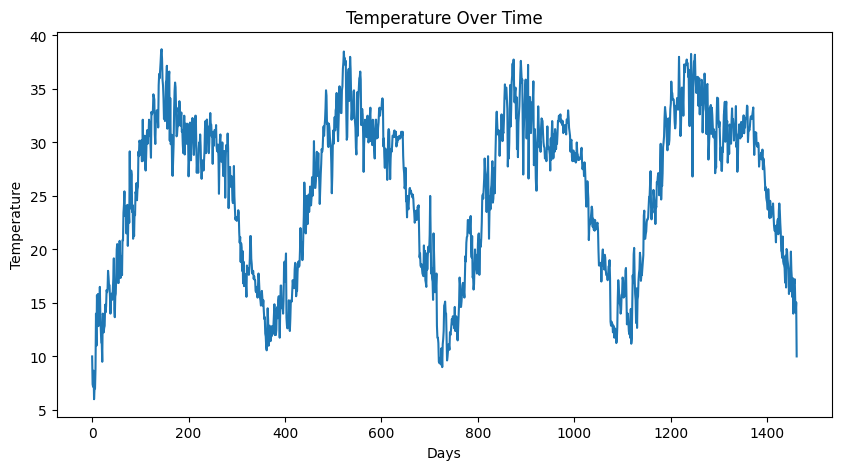

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['meantemp'])
plt.title("Temperature Over Time")
plt.xlabel("Days")
plt.ylabel("Temperature")
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

data = df[['meantemp']].values

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)


In [ ]:
X = []
y = []

time_step = 30

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

In [ ]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print("Shape of X:", X.shape)

Shape of X: (1432, 30, 1)


In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(LSTM(50))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [ ]:
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0546
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0074
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0058
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0055
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0054
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0053
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0052
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0052
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0052
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0047
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0047
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0046
Epoch 13/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0047
Epoch 14/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0047
Epoch 15/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0044
Epoc

In [ ]:
predictions = model.predict(X_test)

# Convert back to original scale
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step


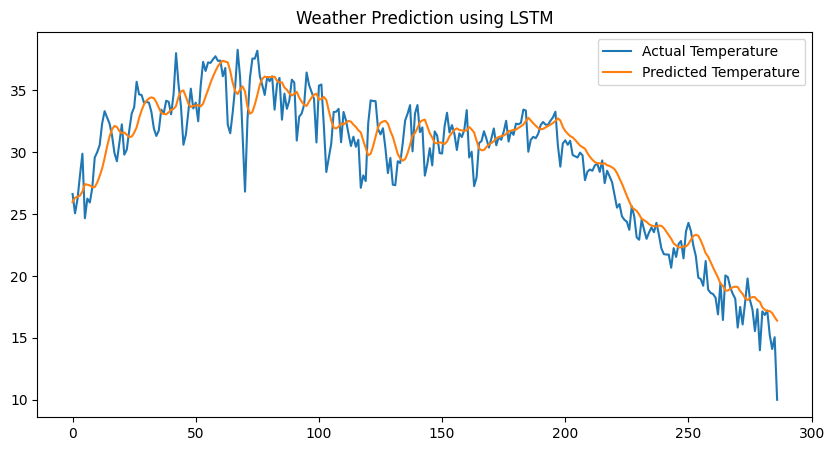

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label='Actual Temperature')
plt.plot(predictions, label='Predicted Temperature')

plt.legend()
plt.title("Weather Prediction using LSTM")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 2.0202752054351136
